In [2]:
rm(list = ls())
gc()

library(Seurat)
library(dplyr)

library("SymSim")


setwd('/mnt/data00/Minghui/project_NMF/10_simlate_count/')

cluster_cols <- c(
  "#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72",
  "#B17BA6", "#FF7F00", "#FDB462", "#E7298A", "#E78AC3",
  "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D",
  "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999",
  "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000",
  "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00")

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,7559474,403.8,13765224,735.2,8792913,469.6
Vcells,13371490,102.1,21470165,163.9,16264858,124.1


In [3]:
library(SymSim)
library(ape)

In [5]:
observed_res <- readRDS('./observed_res.rds')

In [20]:
# Divide the observation counts into batches of 15 and include batch effects
batch_res <- DivideBatches(observed_res, nbatch = 25, batch_effect_size =2)
batch_counts <- batch_res[[1]]   # Count matrix with batch effects
batch_meta <- batch_res[[2]]     # meat lable 
table(batch_meta$batch)


  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19  20 
617 562 581 603 581 583 619 594 605 619 614 586 636 625 594 612 578 543 591 612 
 21  22  23  24  25 
607 577 664 580 617 

In [21]:
library(Seurat)
colnames(batch_counts) <- paste0("Cell", seq_len(ncol(batch_counts)))
rownames(batch_counts) <- paste0("Genes", seq_len(nrow(batch_counts)))

rownames(batch_meta) <- colnames(batch_counts)

seurat_obj <- CreateSeuratObject(counts = batch_counts, 
                                 project = "SymSimData", 
                                 meta.data = batch_meta)
seurat_obj


An object of class Seurat 
7000 features across 15000 samples within 1 assay 
Active assay: RNA (7000 features, 0 variable features)
 2 layers present: counts, data

In [22]:
seurat_obj <- NormalizeData(seurat_obj)  

seurat_obj <- FindVariableFeatures(seurat_obj,selection.method = "vst", nfeatures = 3000 )  

top10 <- head( VariableFeatures(seurat_obj), 10 )
print(top10)

seurat_obj <- ScaleData(seurat_obj)

 [1] "Genes1168" "Genes6085" "Genes4475" "Genes5920" "Genes2647" "Genes3793"
 [7] "Genes1429" "Genes2368" "Genes2744" "Genes3407"


Centering and scaling data matrix



In [23]:
k =20

In [24]:
seurat_obj <- RunPCA(seurat_obj, npcs = k,verbose = FALSE)  

In [25]:
seurat_obj <- FindNeighbors(seurat_obj, dims = 1:k)%>%
 FindClusters()  %>%

 RunUMAP( dims = 1:k) %>% RunTSNE( dims = 1:k)


Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 15000
Number of edges: 667380

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9820
Number of communities: 50
Elapsed time: 0 seconds


11:00:26 UMAP embedding parameters a = 0.9922 b = 1.112

11:00:26 Read 15000 rows and found 20 numeric columns

11:00:26 Using Annoy for neighbor search, n_neighbors = 30

11:00:26 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

11:00:26 Writing NN index file to temp file /tmp/RtmpuG4ZfK/file3d6ba8185d2c38

11:00:26 Searching Annoy index using 1 thread, search_k = 3000

11:00:30 Annoy recall = 100%

11:00:30 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

11:00:32 Found 25 connected components, 
falling back to 'spca' initialization with init_sdev = 1

11:00:32 Using 'irlba' for PCA

11:00:32 PCA: 2 components explained 14.61% variance

11:00:32 Scaling init to sdev = 1

11:00:32 Commencing optimization for 200 epochs, with 6061

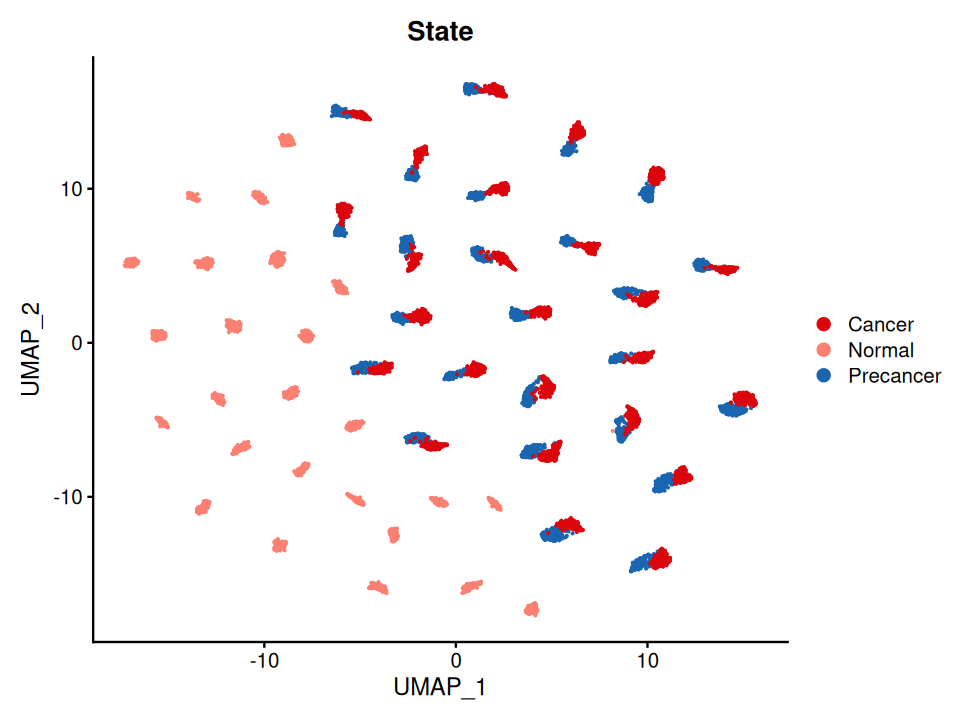

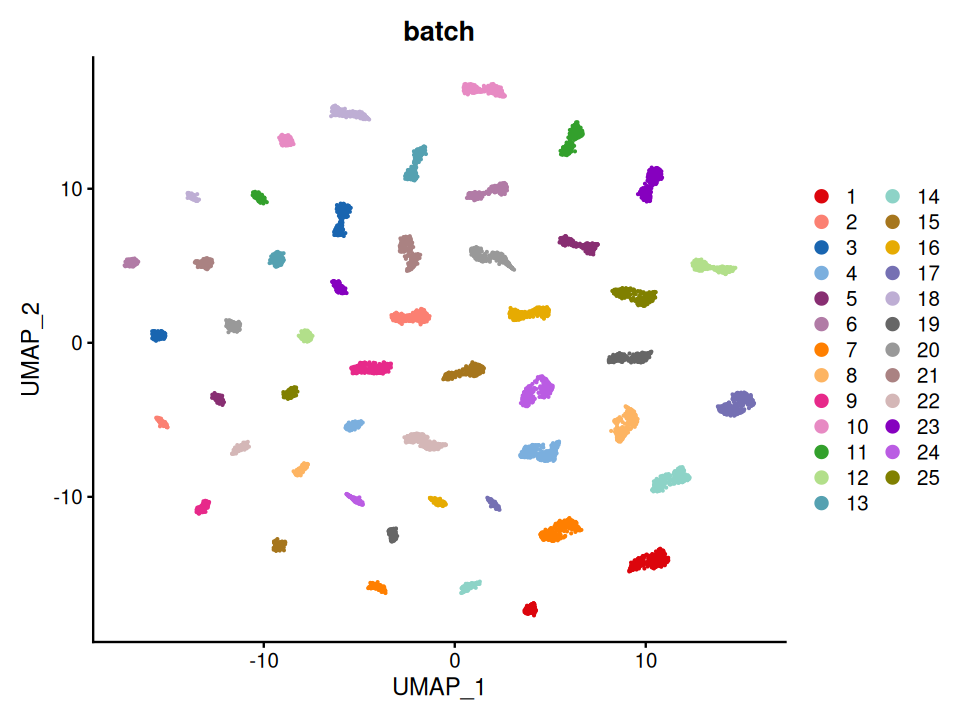

In [27]:
options(repr.plot.width =8, repr.plot.height=6)

DimPlot(seurat_obj, reduction = "umap", group.by = "State" ,cols = cluster_cols)
DimPlot(seurat_obj, reduction = "umap", group.by = "batch",cols = cluster_cols)
# DimPlot(seurat_obj, reduction = "umap", label = TRUE,cols = cluster_cols)  

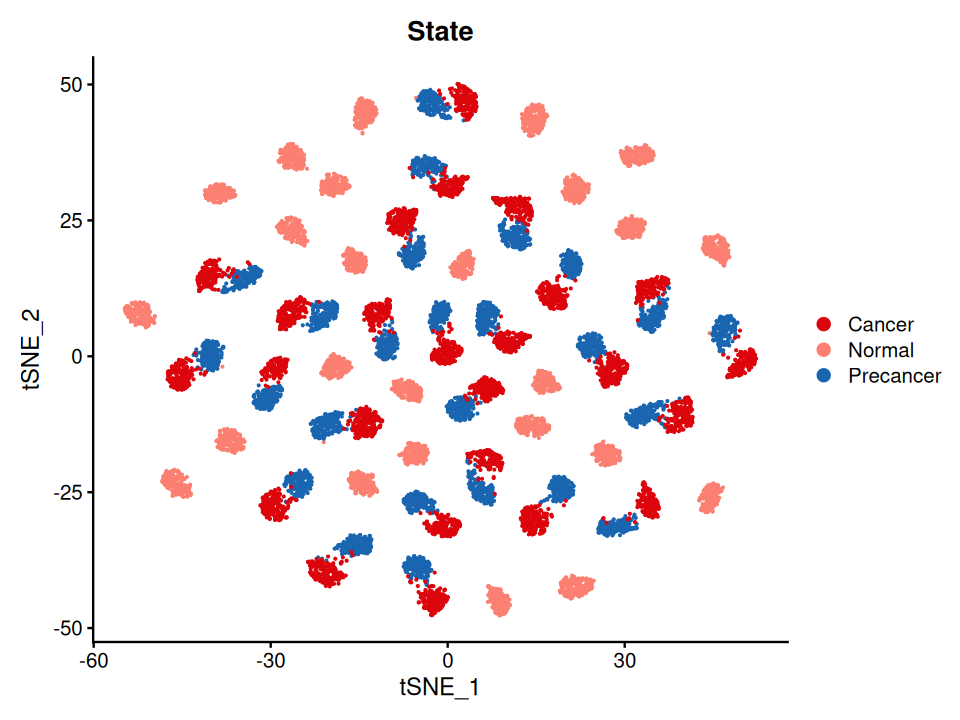

In [28]:
DimPlot(seurat_obj, reduction = "tsne", group.by = "State" ,cols = cluster_cols)


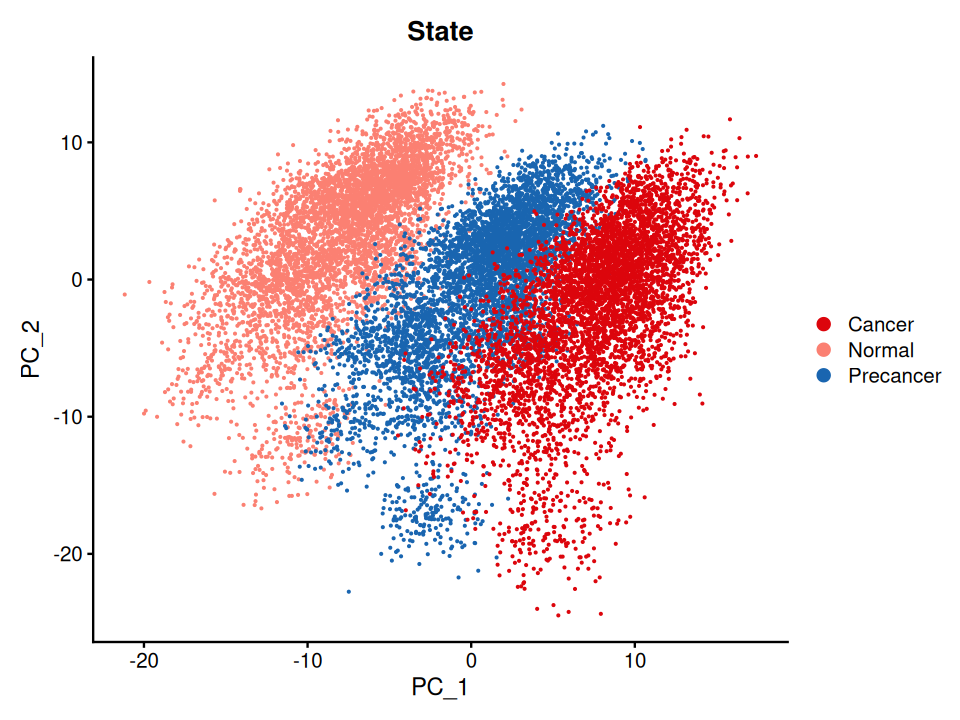

In [29]:
DimPlot(seurat_obj, reduction = "pca", group.by = "State",cols = cluster_cols)


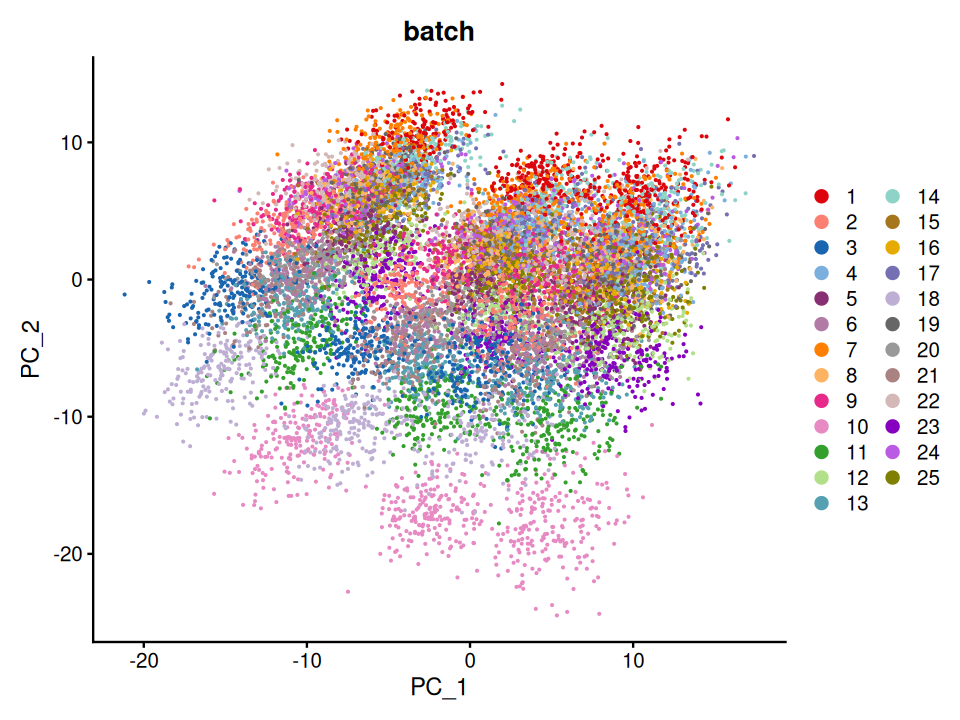

In [30]:
DimPlot(seurat_obj, reduction = "pca", group.by = "batch",cols = cluster_cols)


An object of class Seurat 
7000 features across 15000 samples within 1 assay 
Active assay: RNA (7000 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, tsne

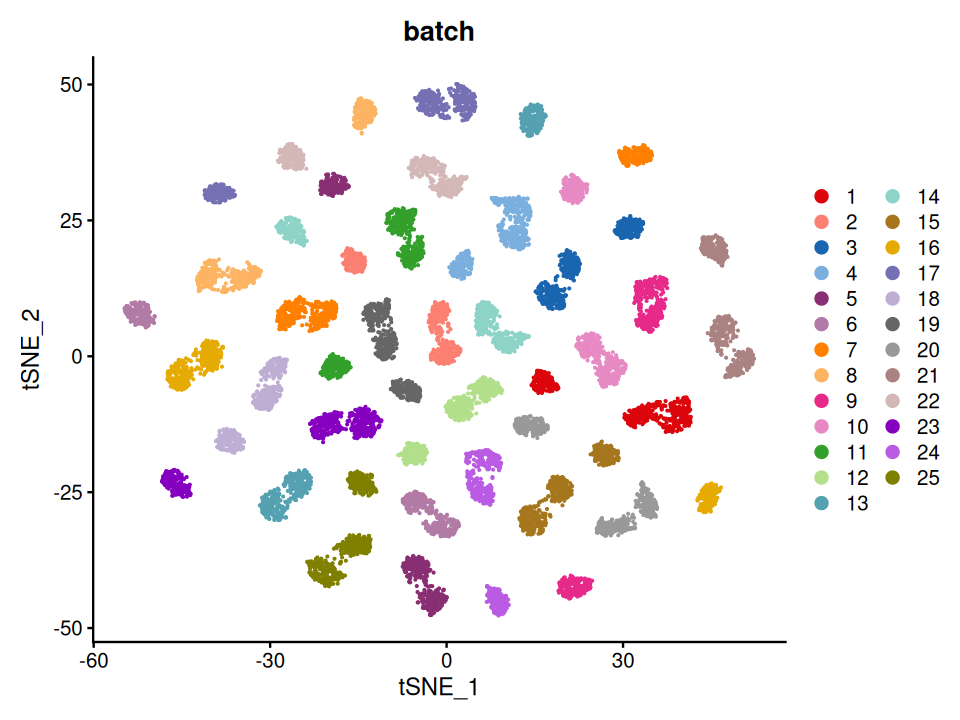

In [31]:
seurat_obj
DimPlot(seurat_obj, reduction = "tsne", group.by = "batch",cols = cluster_cols)

An object of class Seurat 
7000 features across 15000 samples within 1 assay 
Active assay: RNA (7000 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, tsne

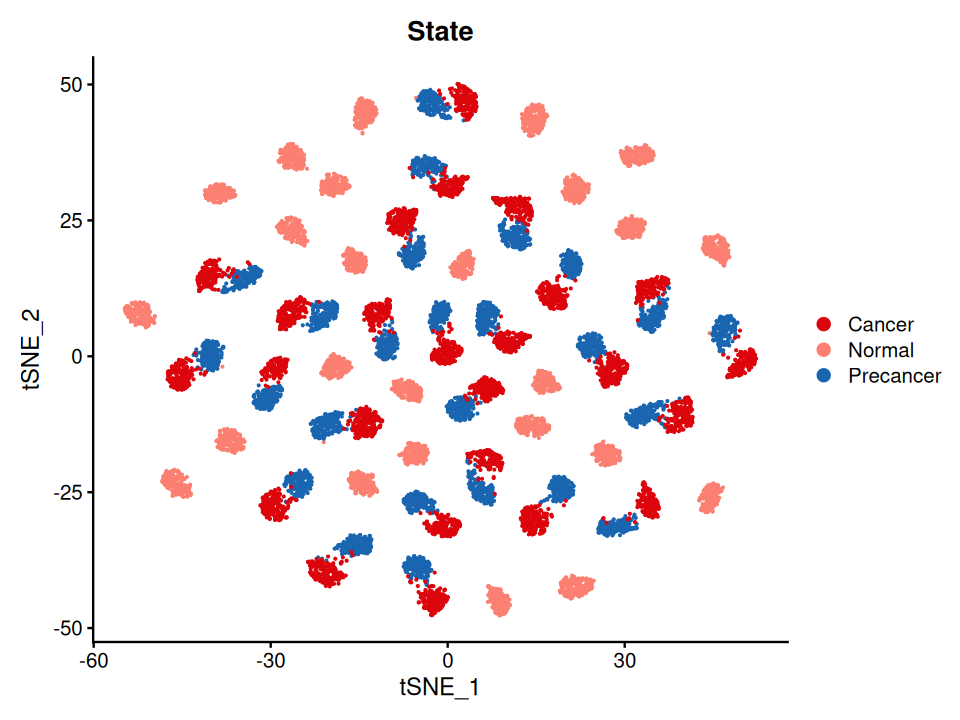

In [32]:
seurat_obj
options(repr.plot.width =8, repr.plot.height=6)

DimPlot(seurat_obj, reduction = "tsne", group.by = "State",cols = cluster_cols)


In [33]:

Idents(seurat_obj) <- 'batch'

split_list <- SplitObject(seurat_obj,split.by = 'batch' )

split_list

$`25`
An object of class Seurat 
7000 features across 617 samples within 1 assay 
Active assay: RNA (7000 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, tsne

$`4`
An object of class Seurat 
7000 features across 603 samples within 1 assay 
Active assay: RNA (7000 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, tsne

$`7`
An object of class Seurat 
7000 features across 619 samples within 1 assay 
Active assay: RNA (7000 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, tsne

$`1`
An object of class Seurat 
7000 features across 617 samples within 1 assay 
Active assay: RNA (7000 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, tsne

$`2`
An object of class Seurat 
7000 features a

In [34]:
#Select HVGs form every sample separatly
hvgs_list <- lapply(split_list, function(seurat_obj) {


    seurat_obj <- FindVariableFeatures(seurat_obj, selection.method = "vst", nfeatures = 3000)
  
    
  VariableFeatures(seurat_obj)
})


names(hvgs_list) <- names(split_list)


In [35]:
all_hvgs <- unlist(hvgs_list)

hvg_counts <- table(all_hvgs)

head(hvg_counts)

hvg_freq_df <- data.frame(
  gene = names(hvg_counts),
  frequency = as.integer(hvg_counts)
)

hvg_freq_df <- hvg_freq_df[order(-hvg_freq_df$frequency), ]

all_hvgs
 Genes100 Genes1000 Genes1001 Genes1002 Genes1004 Genes1005 
       25         2        16         9        22         9 

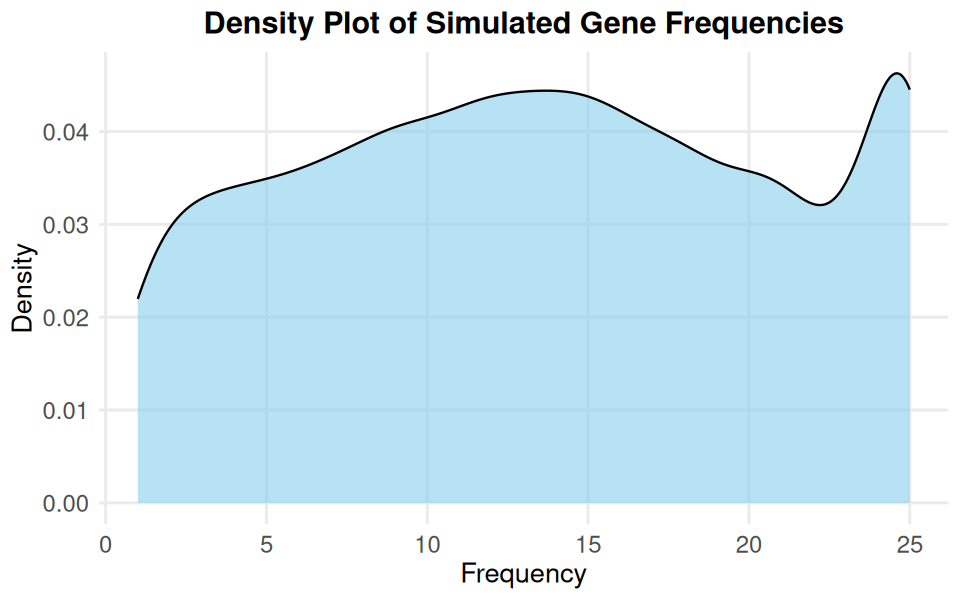

In [36]:
options(repr.plot.width =8, repr.plot.height=5)

ggplot(hvg_freq_df, aes(x = frequency)) +
  geom_density(fill = "skyblue", alpha = 0.6) +
  theme_minimal(base_size = 14) +  
  labs(
    title = "Density Plot of Simulated Gene Frequencies",
    x = "Frequency",
    y = "Density"
  ) +
  theme(
    plot.title = element_text(size = 18, face = "bold", hjust = 0.5),  
    axis.title = element_text(size = 16),
    axis.text = element_text(size = 14),
    panel.grid.minor = element_blank() 
  )


In [37]:
HVGs <- head(hvg_freq_df$gene,3000)

dir <- "/mnt/fast00/Minghui/Simulate_data_06Aug/"

for (i in names(split_list)) {

     sample_dir <- file.path(dir, i)
  if (!dir.exists(sample_dir)) dir.create(sample_dir, recursive = TRUE)

  obj <- ScaleData(split_list[[i]], features = HVGs, do.center = FALSE, verbose = FALSE)
  data <- GetAssayData(obj, slot = "scale.data") %>% as.matrix()
  
  data[data < 0] <- 0
  
  zero_var_rows <- which(apply(data, 1, var) == 0)
  for (j in zero_var_rows) {
    col_index <- sample(ncol(data), 1)
    data[j, col_index] <- 1e-10
  }

  out_file <- file.path(sample_dir, "scaled_matrix.txt")
  write.table(data, file = out_file, sep = "\t", quote = FALSE, row.names = FALSE,col.names = FALSE)

  message("Scaled matrix saved: ", out_file)
}


Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data_06Aug//25/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data_06Aug//4/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data_06Aug//7/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data_06Aug//1/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data_06Aug//2/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data_06Aug//23/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data_06Aug//11/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data_06Aug//14/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data_06Aug//18/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data_06Aug//19/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data_06Aug//21/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data_06Aug//10/scaled_matrix.t

In [43]:
w_dir <- "/mnt/fast00/Minghui/Simulate_data_06Aug/output_csv"


target_files <- sapply(names(split_list), function(sample_name) {
#   k_value <- sample_k_list[[sample_name]]
  file.path(w_dir, paste0(sample_name, "_k", 8, "_theta03_W.csv"))
}, USE.NAMES = TRUE)

print(target_files)


                                                                      25 
"/mnt/fast00/Minghui/Simulate_data_06Aug/output_csv/25_k8_theta03_W.csv" 
                                                                       4 
 "/mnt/fast00/Minghui/Simulate_data_06Aug/output_csv/4_k8_theta03_W.csv" 
                                                                       7 
 "/mnt/fast00/Minghui/Simulate_data_06Aug/output_csv/7_k8_theta03_W.csv" 
                                                                       1 
 "/mnt/fast00/Minghui/Simulate_data_06Aug/output_csv/1_k8_theta03_W.csv" 
                                                                       2 
 "/mnt/fast00/Minghui/Simulate_data_06Aug/output_csv/2_k8_theta03_W.csv" 
                                                                      23 
"/mnt/fast00/Minghui/Simulate_data_06Aug/output_csv/23_k8_theta03_W.csv" 
                                                                      11 
"/mnt/fast00/Minghui/Simulate_data_06A

In [44]:
w_list <- lapply(target_files, function(f) {
  as.matrix(read.csv(f, header = FALSE))
})


names(w_list) <- names(target_files)


print(names(w_list))


 [1] "25" "4"  "7"  "1"  "2"  "23" "11" "14" "18" "19" "21" "10" "22" "9"  "15"
[16] "5"  "12" "20" "3"  "6"  "8"  "24" "13" "17" "16"


In [45]:
gene_names <- HVGs

w_list <- lapply(names(w_list), function(sample_name) {
  mat <- w_list[[sample_name]]
  
  rownames(mat) <- gene_names
  colnames(mat) <- paste0(sample_name, "_Program_", seq_len(ncol(mat)))
  
  return(mat)
})

names(w_list) <- names(w_list)

In [46]:
merge_matrix <- do.call(cbind ,w_list)
mat_unit <- apply(merge_matrix, 2, function(x) x / sqrt(sum(x^2))) #L2 normalize the columns
                

,25_Program_1,25_Program_2,25_Program_3,25_Program_4,25_Program_5,25_Program_6,25_Program_7,25_Program_8,4_Program_1,4_Program_2,⋯,17_Program_7,17_Program_8,16_Program_1,16_Program_2,16_Program_3,16_Program_4,16_Program_5,16_Program_6,16_Program_7,16_Program_8
Genes100,9.131250e-10,1.026313e-03,7.931444e-10,5.966260e-03,9.452278e-10,3.201846e-02,3.740464e-02,0.011794142,9.026459e-10,0.03972247,⋯,3.483416e-02,6.078173e-04,2.867506e-02,2.216839e-02,1.024884e-09,3.084296e-02,9.129222e-10,9.450527e-10,8.126388e-10,1.762217e-02
Genes1006,1.518643e-02,1.698604e-02,2.162871e-02,1.518223e-02,5.629662e-03,1.374952e-02,3.919727e-02,0.012072520,1.322576e-02,0.03959242,⋯,4.239253e-02,8.738757e-03,1.336969e-02,2.097139e-02,1.034961e-02,3.584579e-02,1.912965e-02,1.611214e-02,1.002848e-02,1.952166e-02
Genes1008,1.780141e-02,2.722259e-02,2.427431e-02,1.656970e-02,1.798200e-02,2.495127e-02,7.486729e-03,0.012280580,1.762005e-02,0.01617855,⋯,8.947773e-03,2.294979e-02,2.010389e-03,2.937191e-02,1.941795e-02,6.137018e-10,1.594123e-02,6.979035e-03,3.654444e-02,3.516915e-02
Genes1010,2.128263e-02,2.372876e-02,1.714713e-02,1.691262e-02,1.829079e-02,1.209318e-03,9.295789e-03,0.025466663,1.020287e-02,0.01148286,⋯,7.235751e-03,2.419233e-02,2.650097e-02,6.311249e-03,2.274178e-02,1.531321e-02,2.167356e-02,1.068923e-02,1.790882e-02,1.397396e-02
Genes1019,9.131250e-10,1.005571e-09,7.931444e-10,5.309116e-03,9.452278e-10,9.188990e-10,6.216585e-10,0.065946475,9.026459e-10,0.00868990,⋯,6.200224e-10,3.010466e-05,9.484147e-02,8.289016e-10,1.171560e-02,6.137018e-10,1.286796e-04,9.450527e-10,8.126388e-10,3.123971e-04
Genes1046,7.699527e-03,8.011131e-03,3.200203e-02,9.800596e-10,1.345107e-08,3.182997e-02,2.307536e-02,0.009466648,1.744473e-02,0.01135282,⋯,9.416448e-03,1.114091e-02,9.373609e-10,1.796638e-02,2.226919e-02,1.376128e-02,1.329142e-02,9.450527e-10,3.076981e-02,9.389202e-10


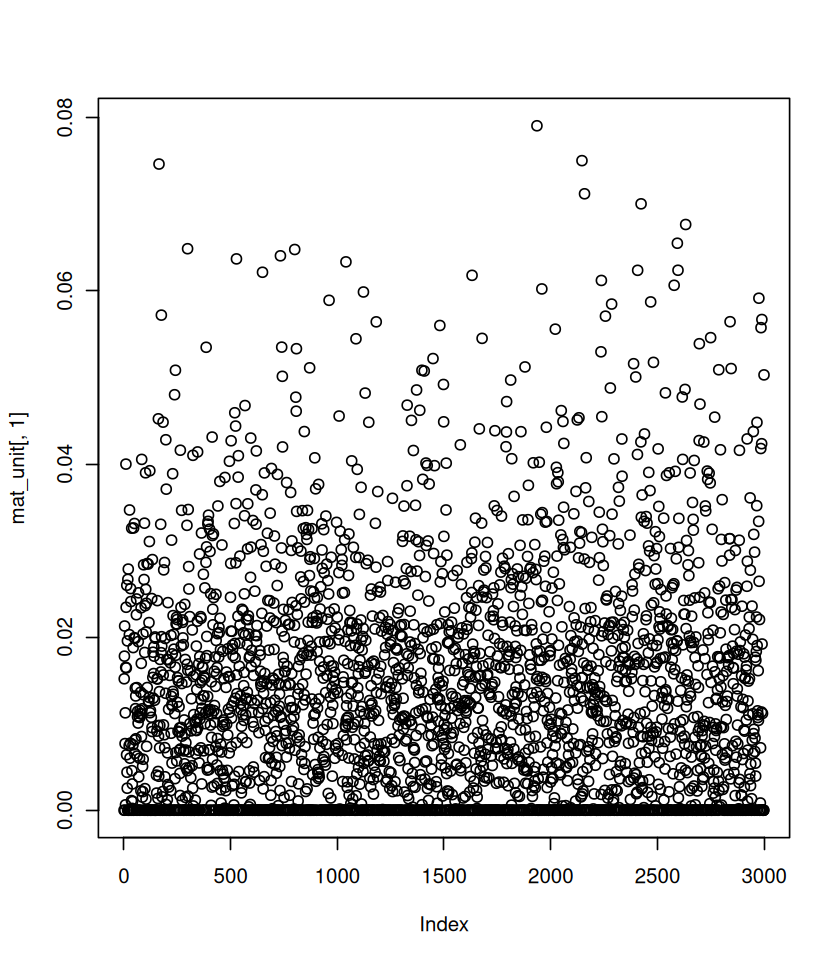

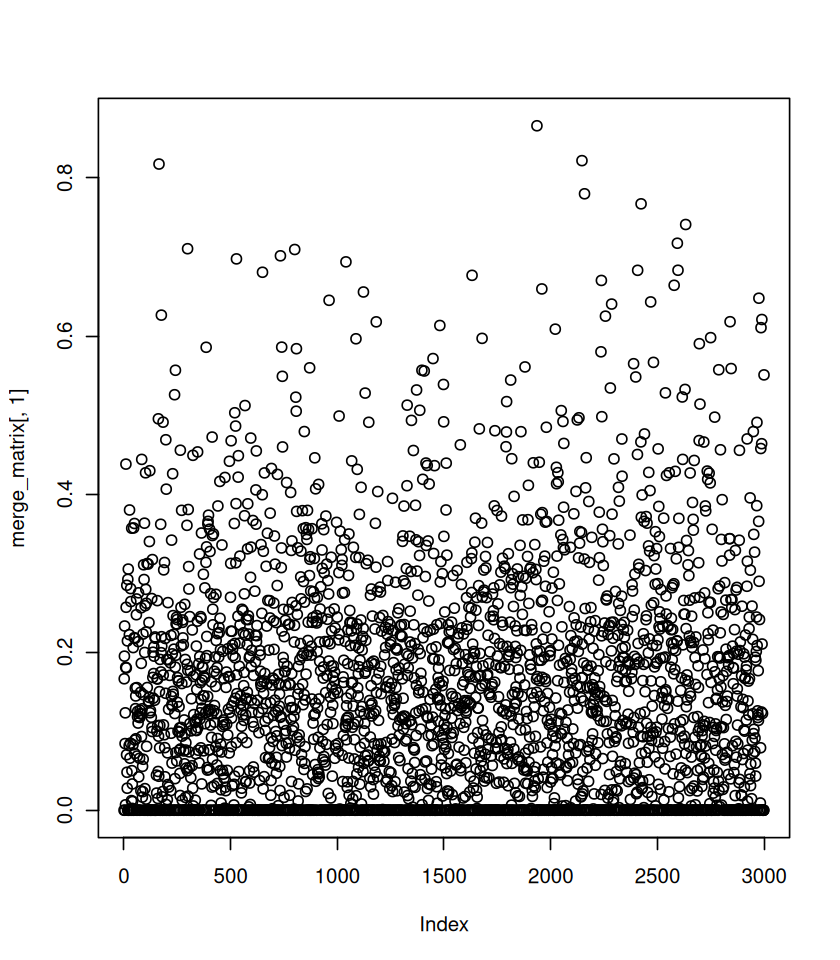

In [47]:
options(repr.plot.width =7, repr.plot.height=8)

head(mat_unit)

plot(mat_unit[,1])

plot(merge_matrix[,1])

In [48]:
library(cluster)


pam_data <- pam(t(mat_unit),20 )

names(pam_data)


Attaching package: ‘cluster’


The following object is masked from ‘package:maps’:

    votes.repub




[1] "medoids"    "id.med"     "clustering" "objective"  "isolation" 
 [6] "clusinfo"   "silinfo"    "diss"       "call"       "data"

Loading required package: permute


Attaching package: ‘vegan’


The following object is masked from ‘package:phytools’:

    scores


Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’



[1] 0.5158805 0.5026447 0.5327200 0.5436467 0.5143176 0.5579860

[1] 11

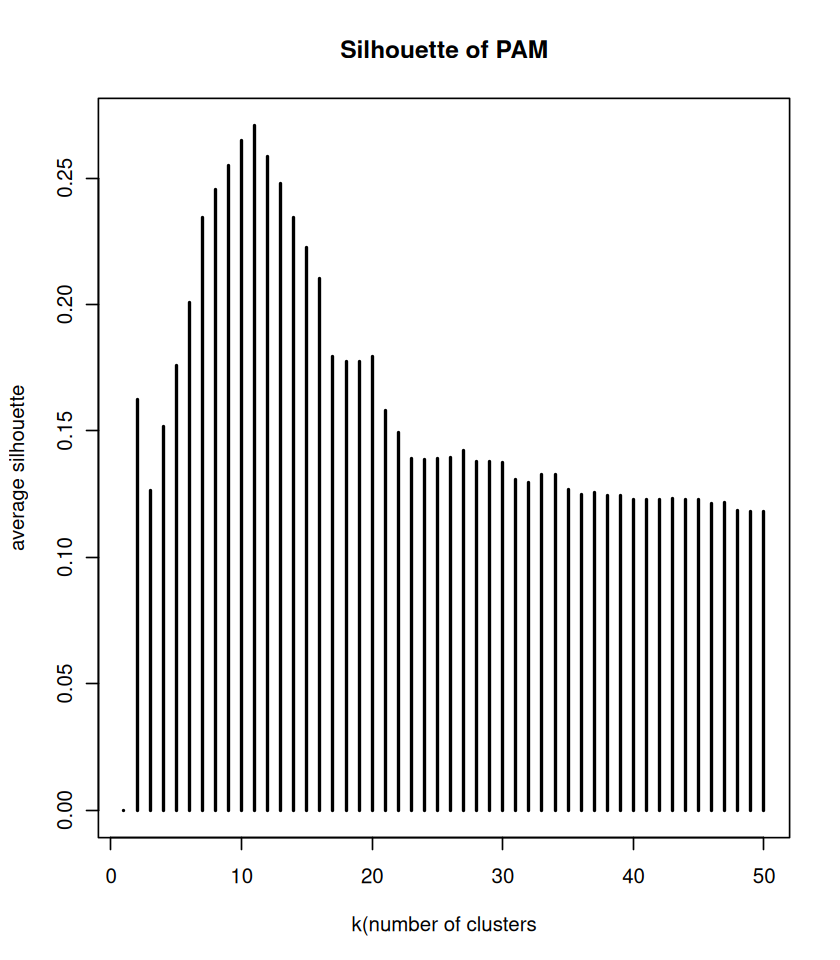

In [49]:
library(vegan)

otu_dist=vegdist(t(mat_unit), method="bray", diag=TRUE, upper=TRUE, p=2)

head(otu_dist)

library(fpc)
library(cluster)
pambest=pamk(otu_dist)
k=pambest$nc

asw <- numeric(50)
for (i in 2:50) {
  asw[i]=pam(otu_dist, i)$silinfo$avg.width
}
k.best=which.max(asw)
plot(1:length(asw), asw, type="h", main="Silhouette of PAM", lwd=2,
     xlab="k(number of clusters", ylab="average silhouette")

k.best

In [50]:
k = k.best

pam_data <- pam(t(mat_unit),k )
medoid_names <- pam_data$medoids

medoid_vectors <- mat_unit[, rownames( pam_data$medoids)]

w_list <- lapply(target_files, function(f) {
  as.matrix(read.csv(f, header = FALSE))
})

names(w_list) <- names(target_files)

print(names(w_list))


 [1] "25" "4"  "7"  "1"  "2"  "23" "11" "14" "18" "19" "21" "10" "22" "9"  "15"
[16] "5"  "12" "20" "3"  "6"  "8"  "24" "13" "17" "16"


In [51]:
head(medoid_vectors)

dim(medoid_vectors)

seurat_sim <- subset(seurat_obj,batch%in% names(w_list))
seurat_sim  <- ScaleData(object = seurat_sim,do.center = F,features =rownames(merge_matrix) )  
norm_expression <- seurat_sim@assays$RNA@scale.data


,20_Program_5,9_Program_8,3_Program_6,12_Program_1,6_Program_1,20_Program_3,23_Program_3,13_Program_6,20_Program_7,22_Program_7,16_Program_8
Genes100,8.903047e-10,5.086722e-03,1.372158e-07,9.241207e-10,2.243702e-02,4.458125e-02,0.021199594,8.834904e-10,9.680930e-10,6.874699e-03,1.762217e-02
Genes1006,1.170686e-02,1.904660e-02,1.463062e-02,1.766316e-02,1.413495e-02,4.206756e-02,0.017886108,2.145793e-02,1.110539e-02,2.300710e-02,1.952166e-02
Genes1008,2.167757e-02,2.952939e-02,3.555621e-03,2.100474e-02,1.900128e-02,5.811927e-03,0.003783063,5.201022e-03,1.689794e-02,2.813051e-02,3.516915e-02
Genes1010,5.680333e-03,2.169286e-02,2.574221e-02,3.275392e-02,1.160920e-03,1.385813e-02,0.024222622,2.238521e-02,3.841564e-02,2.554014e-02,1.397396e-02
Genes1019,8.903047e-10,8.879768e-10,3.908591e-03,9.241207e-10,9.221306e-10,6.389748e-10,0.082534667,8.834904e-10,9.680930e-10,8.090239e-10,3.123971e-04
Genes1046,1.257057e-02,1.441764e-02,2.179613e-02,2.429530e-02,2.811766e-02,1.188590e-02,0.021231518,8.834904e-10,1.077210e-02,3.845129e-02,9.389202e-10


[1] 3000   11

Scaling data matrix



In [52]:
compute_usage_matrix_parallel <- function(norm_expression, norm_components, n_cores = NULL) {
  
  library(nnls)
  library(doParallel)
  library(foreach)
  

  n_cells <- ncol(norm_expression)
  n_components <- ncol(norm_components)
  usage_matrix <- matrix(0, nrow = n_cells, ncol = n_components)
  rownames(usage_matrix) <- colnames(norm_expression)
  colnames(usage_matrix) <- colnames(norm_components)
  
  cl <- makeCluster(n_cores)
  registerDoParallel(cl)
  
  clusterExport(cl, c("norm_components"), envir = environment())
  
  # NNLS
  usage_list <- foreach(i = 1:n_cells, .packages = "nnls") %dopar% {
    fit <- nnls::nnls(norm_components, norm_expression[, i])
    fit$x
  }
  
  stopCluster(cl)
  
  usage_matrix <- do.call(rbind, usage_list)
  rownames(usage_matrix) <- colnames(norm_expression)
  colnames(usage_matrix) <- colnames(norm_components)
  
  return(usage_matrix)
}

In [53]:
# Parallel 
chunk_size <- 1000  # cell number in every chunks
chunks <- split(1:ncol(norm_expression), ceiling(seq_along(1:ncol(norm_expression))/chunk_size))

results <- lapply(chunks, function(idx) {
  compute_usage_matrix_parallel(norm_expression[, idx],n_cores = 25, medoid_vectors)
})

usage_matrix <- do.call(rbind, results)

Loading required package: foreach

Loading required package: iterators

Loading required package: parallel



In [54]:
seurat_sim[['Consensus']] <- CreateDimReducObject(
  embeddings = as.matrix(usage_matrix),  # Ensure this is a numeric matrix
  key = 'Consensus_',  # Set the key for the reduction
  assay = 'RNA'  # Specify the assay if necessary
)

In [55]:
# n =30

seurat_sim <- FindNeighbors(seurat_sim, dims = 1:k, reduction = 'Consensus')
seurat_sim <- RunUMAP(seurat_sim, reduction = 'Consensus', dims = 1:k)

seurat_sim <- FindClusters(seurat_sim,resolution = 1.5 )

# resolution = 1 32 clusters

# resolution = 1.5 41 clusters
# resolution = 2 46 clusters

Computing nearest neighbor graph

Computing SNN

11:10:12 UMAP embedding parameters a = 0.9922 b = 1.112

11:10:12 Read 15000 rows and found 11 numeric columns

11:10:12 Using Annoy for neighbor search, n_neighbors = 30

11:10:12 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

11:10:13 Writing NN index file to temp file /tmp/RtmpuG4ZfK/file3d6ba843d50784

11:10:13 Searching Annoy index using 1 thread, search_k = 3000

11:10:18 Annoy recall = 100%

11:10:19 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

11:10:20 Initializing from normalized Laplacian + noise (using irlba)

11:10:20 Commencing optimization for 200 epochs, with 534996 positive edges

11:10:20 Using rng type: pcg

11:10:25 Optimization finished



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 15000
Number of edges: 355242

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.6404
Number of communities: 23
Elapsed time: 1 seconds


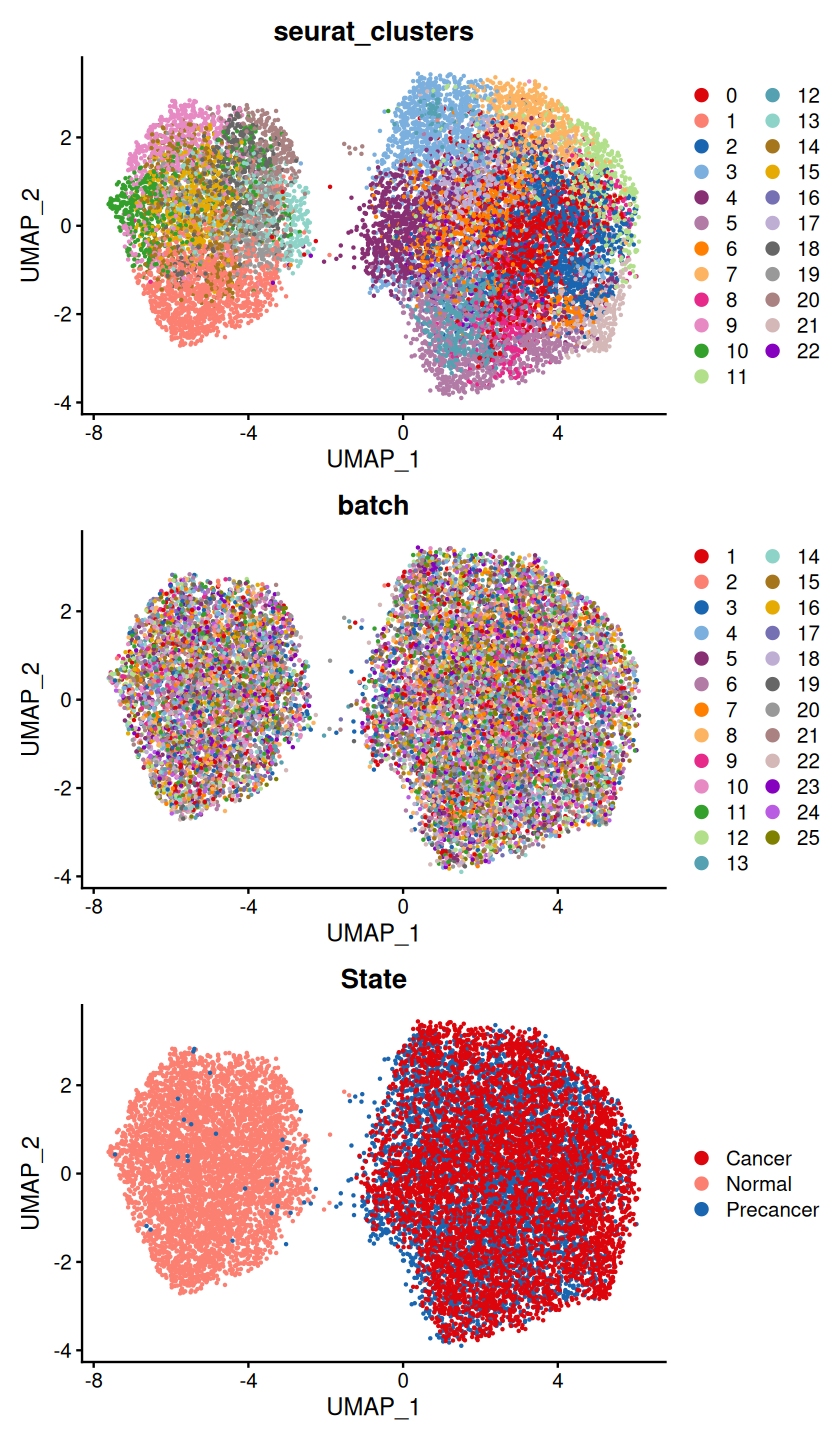

In [56]:
options(repr.plot.width =7, repr.plot.height=12)

DimPlot(seurat_sim,reduction = "umap",group.by = c("seurat_clusters","batch","State"),raster=FALSE,pt.size = 0.2,ncol = 1,cols =  rep(cluster_cols,3))

Loading required package: Rcpp

Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony 4/10

Harmony 5/10

Harmony 6/10

Harmony 7/10

Harmony 8/10

Harmony 9/10

Harmony 10/10

11:12:13 UMAP embedding parameters a = 0.9922 b = 1.112

11:12:13 Read 15000 rows and found 11 numeric columns

11:12:13 Using Annoy for neighbor search, n_neighbors = 30

11:12:13 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

11:12:14 Writing NN index file to temp file /tmp/RtmpuG4ZfK/file3d6ba847f4e039

11:12:14 Searching Annoy index using 1 thread, search_k = 3000

11:12:17 Annoy recall = 100%

11:12:18 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

11:12:20 Found 2 conn

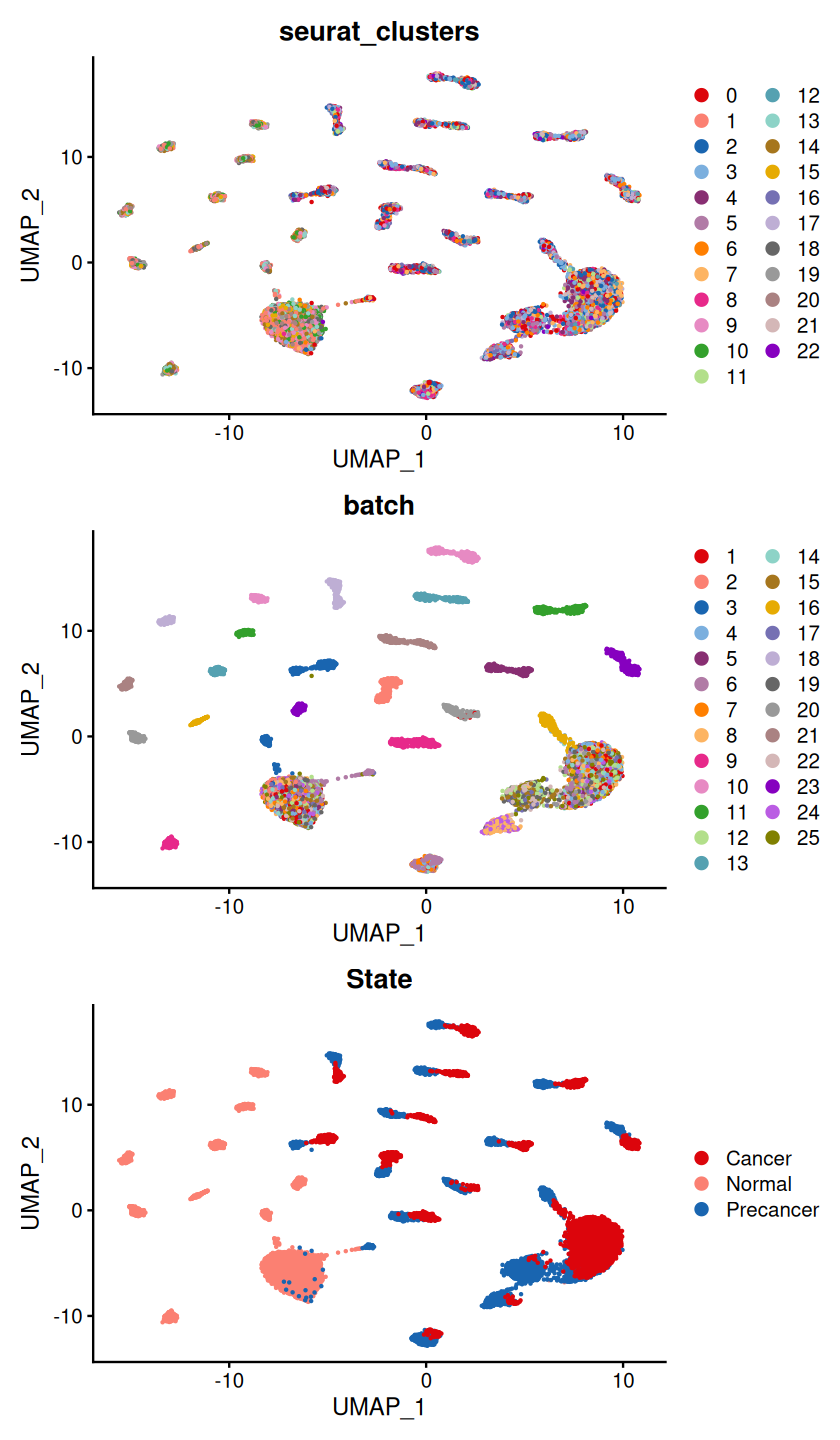

In [57]:
library(harmony)
seurat_sim <- RunHarmony(seurat_sim,lambda = 1, group.by.vars = 'batch')
seurat_sim <- RunUMAP(seurat_sim, reduction = 'harmony', dims = 1:k)
options(repr.plot.width =7, repr.plot.height=12)

DimPlot(seurat_sim,reduction = "umap",group.by = c("seurat_clusters","batch","State"),raster=FALSE,pt.size = 0.2,ncol = 1,cols =  rep(cluster_cols,3))